# India — State-wise Installed Power Capacity: Cleaning & Validation

**Grain:** one row per *state × sector × month*

In [1]:
import pandas as pd    
import numpy as np

In [2]:
df = pd.read_csv(r'C:\Users\v-vvajpai\Desktop\Project\Project_2\datasets\installed-capacity-statewise.csv')

In [3]:
print('shape of the dataset:', df.shape)

shape of the dataset: (9336, 13)


In [4]:
print('data types of the dataset:', df.dtypes)

data types of the dataset: id               int64
date            object
region          object
state_name      object
state_code       int64
sector          object
coal_cap       float64
gas_cap        float64
diesel_cap     float64
lignite_cap    float64
nuclear_cap    float64
hydro_cap      float64
res_cap        float64
dtype: object


- `date` came in as a string, so **convert to datetime** 

In [4]:
print(df.head(9))

   id        date   region                   state_name  state_code   sector  \
0   0  2017-11-01  Eastern  Andaman And Nicobar Islands          35  Central   
1   1  2017-11-01  Eastern  Andaman And Nicobar Islands          35  Private   
2   2  2017-11-01  Eastern  Andaman And Nicobar Islands          35    State   
3   3  2017-11-01  Eastern                        Bihar          10  Central   
4   4  2017-11-01  Eastern                        Bihar          10  Private   
5   5  2017-11-01  Eastern                        Bihar          10    State   
6   6  2017-11-01  Eastern                    Jharkhand          20  Central   
7   7  2017-11-01  Eastern                    Jharkhand          20  Private   
8   8  2017-11-01  Eastern                    Jharkhand          20    State   

   coal_cap  gas_cap  diesel_cap  lignite_cap  nuclear_cap  hydro_cap  res_cap  
0       0.0      0.0        0.00          0.0         0.00        0.0      0.0  
1       0.0      0.0        0.00     


- Lots of zeros in the fuel columns. That's expected — most states simply don't have nuclear or diesel capacity etc — so zeros are expected

In [5]:
df.isna().sum()

id             0
date           0
region         0
state_name     0
state_code     0
sector         0
coal_cap       0
gas_cap        0
diesel_cap     0
lignite_cap    0
nuclear_cap    0
hydro_cap      0
res_cap        0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
keys = ['state_name', 'sector', 'date']
df.duplicated(subset=keys).sum()

np.int64(0)

- **0** missing cells anywhere.
- **0** fully-duplicated rows.
- **0** duplicates on the natural key `(state_name, sector, date)` — so the grain is
  exactly one row per state-sector-month, as advertised.


state codes and state names should be a stable 1-to-1 mapping.

In [8]:
codes_with_multiple_names = df.groupby("state_code")["state_name"].nunique()
# State code having more than 1 unique state name. 
print(codes_with_multiple_names[codes_with_multiple_names > 1])

Series([], Name: state_name, dtype: int64)


In [9]:
grid = df.pivot_table(index="state_name", columns="date",
                      values="state_code", aggfunc="first")

In [10]:
changing = grid[grid.nunique(axis=1) > 1]

pd.set_option("display.width", 200, "display.max_columns", 20)
print(changing)

Empty DataFrame
Columns: [2017-11-01, 2017-12-01, 2018-01-01, 2018-02-01, 2018-03-01, 2018-04-01, 2018-05-01, 2018-06-01, 2018-07-01, 2018-08-01, 2018-09-01, 2018-10-01, 2018-11-01, 2018-12-01, 2019-01-01, 2019-02-01, 2019-03-01, 2019-04-01, 2019-05-01, 2019-06-01, 2019-07-01, 2019-08-01, 2019-09-01, 2019-10-01, 2019-11-01, 2019-12-01, 2020-01-01, 2020-02-01, 2020-03-01, 2020-04-01, 2020-05-01, 2020-06-01, 2020-07-01, 2020-08-01, 2020-09-01, 2020-10-01, 2020-11-01, 2020-12-01, 2021-01-01, 2021-02-01, 2021-03-01, 2021-04-01, 2021-05-01, 2021-06-01, 2021-07-01, 2021-08-01, 2021-09-01, 2021-10-01, 2021-11-01, 2021-12-01, 2022-01-01, 2022-02-01, 2022-03-01, 2022-04-01, 2022-05-01, 2022-06-01, 2022-07-01, 2022-08-01, 2022-09-01, 2022-10-01, 2022-11-01, 2022-12-01, 2023-01-01, 2023-02-01, 2023-03-01, 2023-04-01, 2023-05-01, 2023-06-01, 2023-07-01, 2023-08-01, 2023-09-01, 2023-10-01, 2023-11-01, 2023-12-01, 2024-01-01, 2024-02-01, 2024-03-01, 2024-04-01, 2024-05-01, 2024-06-01, 2024-07-01, 20

Every `state_code` maps to exactly one `state_name`
across all months, and the code assigned to each state never changes over time. 

In [15]:
df["date"] = pd.to_datetime(df["date"])

In [16]:
CAPS = ["coal_cap","gas_cap","diesel_cap","lignite_cap",
        "nuclear_cap","hydro_cap","res_cap"]

In [17]:
df.shape, df["date"].min(), df["date"].max()

((9336, 13),
 Timestamp('2017-11-01 00:00:00'),
 Timestamp('2025-03-01 00:00:00'))

In [15]:
print(df.dtypes, "\n")
print("dates:", df["date"].nunique(), "| states:", df["state_name"].nunique(),
      "| sectors:", df["sector"].unique())
print("full-row dupes:", df.duplicated().sum())
df[CAPS].describe().T[["min","max","mean"]]

id                      int64
date           datetime64[ns]
region                 object
state_name             object
state_code              int64
sector                 object
coal_cap              float64
gas_cap               float64
diesel_cap            float64
lignite_cap           float64
nuclear_cap           float64
hydro_cap             float64
res_cap               float64
dtype: object 

dates: 89 | states: 36 | sectors: ['Central' 'Private' 'State']
full-row dupes: 0


,min,max,mean
coal_cap,0.0,13168.00,1951.390601
gas_cap,0.0,4663.14,237.550119
diesel_cap,0.0,411.70,5.683488
lignite_cap,0.0,3390.00,28.363325
nuclear_cap,0.0,15569.41,465.628693
hydro_cap,0.0,7884.02,236.407700
res_cap,0.0,33357.49,808.573473


 Every fuel column is non-negative (no impossible negative
capacity), spans the full Nov-2017 → Mar-2025 window, and the min/max ranges look
physically plausible for state-level MW figures. 

## plotting the series over time

Summary statistics hide time-structure. A column can have a perfectly reasonable
min/mean/max and still contain a step-change that makes it useless. So before declaring
the data clean, I plotted the national total of each fuel month-by-month.

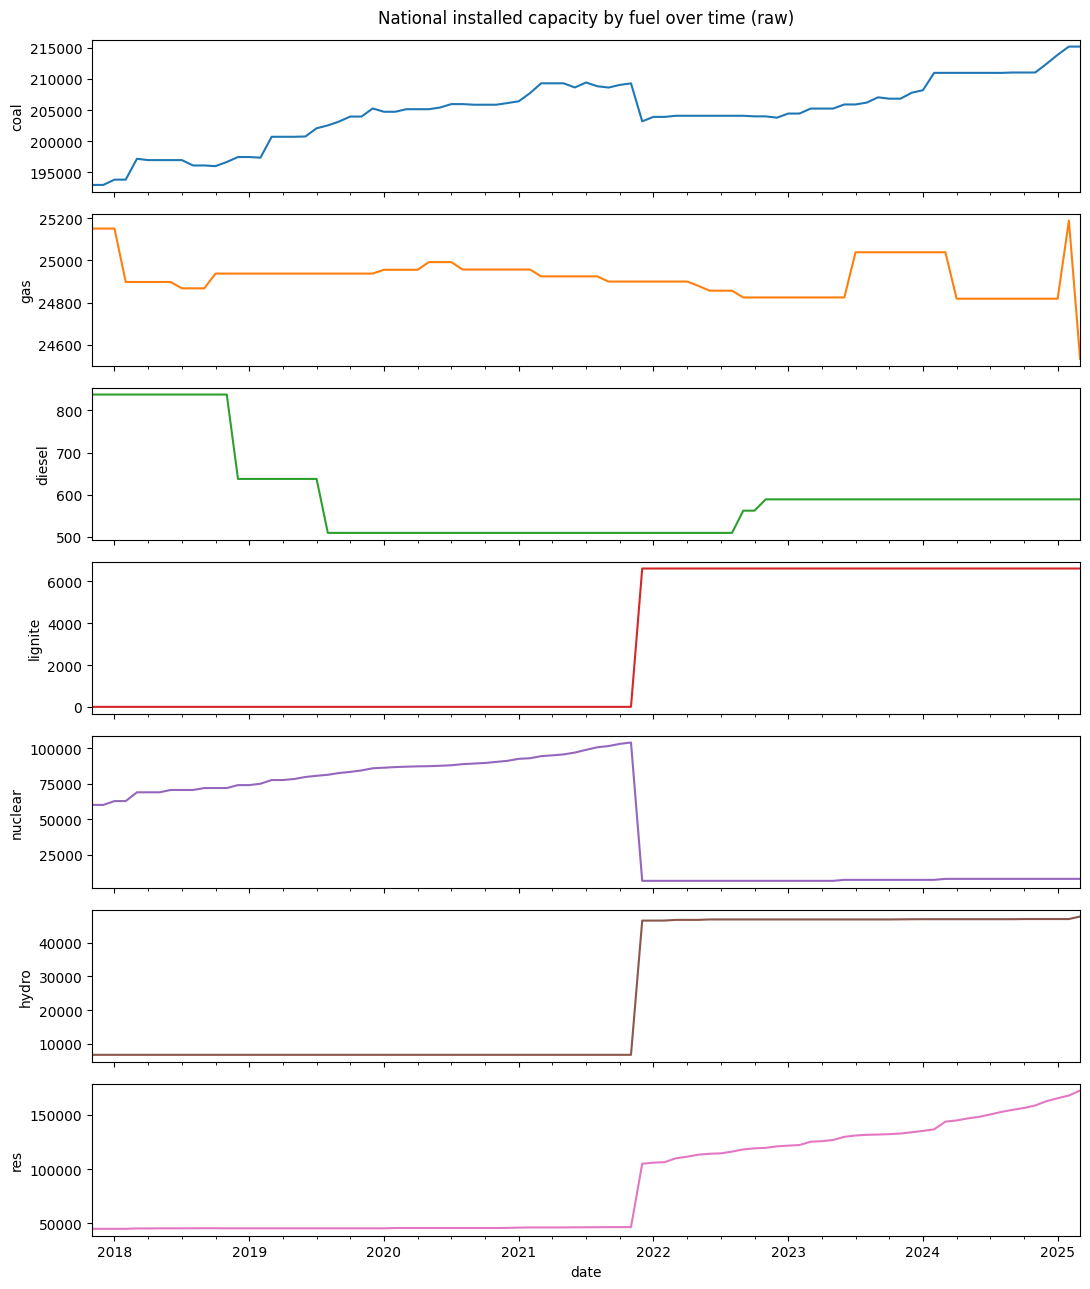

In [18]:
import matplotlib.pyplot as plt

# National monthly total for each fuel, plotted as small multiples.
# This is exploratory — it is the RAW data, before any fix.
axes = (df.groupby("date")[CAPS].sum()
          .plot(subplots=True, figsize=(11, 13), legend=False))
for ax, col in zip(axes, CAPS):
    ax.set_ylabel(col.replace("_cap", ""))
axes[0].set_title("National installed capacity by fuel over time (raw)", pad=12)
plt.tight_layout()
plt.show()

**nuclear**, **hydro** and **res** and **lignite** show an
step around late-2021 — Something is wrong with those three columns before that point. 

In India, nuclear generation is centrally owned — no State or Private utility operates a
reactor. So `nuclear_cap > 0` in a non-Central row is physically impossible. 

In [19]:
print(df.groupby("sector")["nuclear_cap"].sum())

sector
Central     370803.10
Private    3865707.42
State       110598.96
Name: nuclear_cap, dtype: float64


In [20]:
violations = df[(df["sector"] != "Central") & (df["nuclear_cap"] > 0)]
print("\nImpossible 'non-Central nuclear' rows:", len(violations))
print(violations.nlargest(3, "nuclear_cap")[["date","state_name","sector","nuclear_cap"]])


Impossible 'non-Central nuclear' rows: 3180
           date  state_name   sector  nuclear_cap
5061 2021-11-01   Karnataka  Private     15569.41
4955 2021-10-01   Karnataka  Private     15540.41
5073 2021-11-01  Tamil Nadu  Private     15514.59


There are non-Central rows carrying nuclear
capacity — that can't be right. Combined with the step-change above, the pattern points
at the nuclear column specifically.

In [21]:
nat = df.groupby("date")["nuclear_cap"].sum()
print(nat.loc["2021-08-01":"2022-02-01"].round(0))

date
2021-08-01    100683.0
2021-09-01    101533.0
2021-10-01    103055.0
2021-11-01    104031.0
2021-12-01      6780.0
2022-01-01      6780.0
2022-02-01      6780.0
Name: nuclear_cap, dtype: float64


In [22]:
break_at = nat.diff().abs().idxmax()
print("\nLargest discontinuity at:", break_at.date(),
      "| change:", round(nat.diff().loc[break_at]), "MW")


Largest discontinuity at: 2021-12-01 | change: -97251 MW


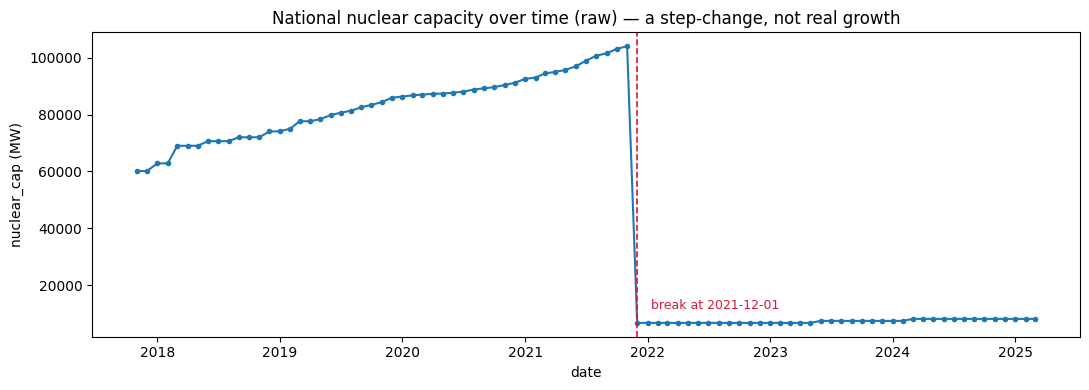

In [23]:
# Visualise the discontinuity: national nuclear total over time,
# with the largest month-to-month jump marked.
nat_raw = df.groupby("date")["nuclear_cap"].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nat_raw.index, nat_raw.values, marker="o", ms=3, color="#1f77b4")
ax.axvline(break_at, color="crimson", ls="--", lw=1.2)
ax.annotate(f"break at {break_at.date()}",
            xy=(break_at, nat_raw.loc[break_at]),
            xytext=(10, 10), textcoords="offset points",
            color="crimson", fontsize=9)
ax.set_title("National nuclear capacity over time (raw) — a step-change, not real growth")
ax.set_xlabel("date"); ax.set_ylabel("nuclear_cap (MW)")
plt.tight_layout(); plt.show()

The largest discontinuity is at the
**Nov-2021 → Dec-2021** boundary. Everything *from Dec-2021 onward* looks correct;
everything *before* is where the problem lives. That gives me a clean before/after line
to work with: `LAST_BAD = 2021-11-01`, `BOUNDARY = 2021-12-01`.

My hypothesis: the last three columns — `nuclear`, `hydro`, `res` — were **rotated**
(mislabeled) in the source system before Dec-2021, and fixed from Dec-2021 on. To test
it I compare the same state/sector across the Nov→Dec boundary. If the values simply
*shift between the three columns* rather than jumping randomly, the rotation theory holds.

In [24]:
BOUNDARY = pd.Timestamp("2021-12-01")   
LAST_BAD  = pd.Timestamp("2021-11-01")

trio = ["nuclear_cap", "hydro_cap", "res_cap"]
m = (df["state_name"]=="Tamil Nadu") & (df["sector"]=="Central") \
    & (df["date"].isin([LAST_BAD, BOUNDARY]))
df[m][["date"]+trio]

,date,nuclear_cap,hydro_cap,res_cap
5072,2021-11-01,231.9,2440.0,0.0
5178,2021-12-01,2440.0,0.0,231.9


In [25]:
for st, sec in [("Gujarat","Central"), ("Rajasthan","State"), ("Maharashtra","Central")]:
    m = (df.state_name==st)&(df.sector==sec)&(df.date.isin([LAST_BAD, BOUNDARY]))
    print(f"\n{st}/{sec}"); print(df[m][["date"]+trio].to_string(index=False))


Gujarat/Central
      date  nuclear_cap  hydro_cap  res_cap
2021-11-01        243.3      440.0      0.0
2021-12-01        440.0        0.0    243.3

Rajasthan/State
      date  nuclear_cap  hydro_cap  res_cap
2021-11-01        23.85        0.0   411.00
2021-12-01         0.00      411.0    23.85

Maharashtra/Central
      date  nuclear_cap  hydro_cap  res_cap
2021-11-01        123.0     1400.0      0.0
2021-12-01       1400.0        0.0    123.0


**Diagnosis confirmed — it's a column rotation, not corrupt numbers.** Across the
boundary the *values don't change magnitude, they change column*. For the pre-Dec-2021
rows the mapping is a clean 3-cycle:

| Column as labelled (pre-Dec-2021) | Value it actually holds |
|---|---|
| `nuclear_cap` | really **hydro** |
| `hydro_cap`   | really **res** |
| `res_cap`     | really **nuclear** |

That single, consistent shift explains *both* symptoms at once: the impossible
non-Central "nuclear", and the step-change at the boundary. Because it's a deterministic
relabelling, I can reverse it exactly rather than guessing or dropping data — the best
possible outcome.

In [26]:
fixed = df.copy()
early = fixed["date"] <= LAST_BAD
onu, ohy, ore = (fixed.loc[early,"nuclear_cap"].copy(),
                 fixed.loc[early,"hydro_cap"].copy(),
                 fixed.loc[early,"res_cap"].copy())
fixed.loc[early,"nuclear_cap"] = ohy
fixed.loc[early,"hydro_cap"]   = ore
fixed.loc[early,"res_cap"]     = onu

**Decision recorded:** only rows with `date <= 2021-11-01` are rotated back; later rows
are left untouched. Using a temp copy of the three columns avoids overwriting a value
before it's been read.

In [27]:
bad = ((fixed.sector!="Central") & (fixed.nuclear_cap>0)).sum()

In [28]:
nat = fixed.groupby("date")["nuclear_cap"].sum()
print("non-Central nuclear rows:", bad, "| nuclear range:", round(nat.min()), "-", round(nat.max()))

non-Central nuclear rows: 0 | nuclear range: 6780 - 8180


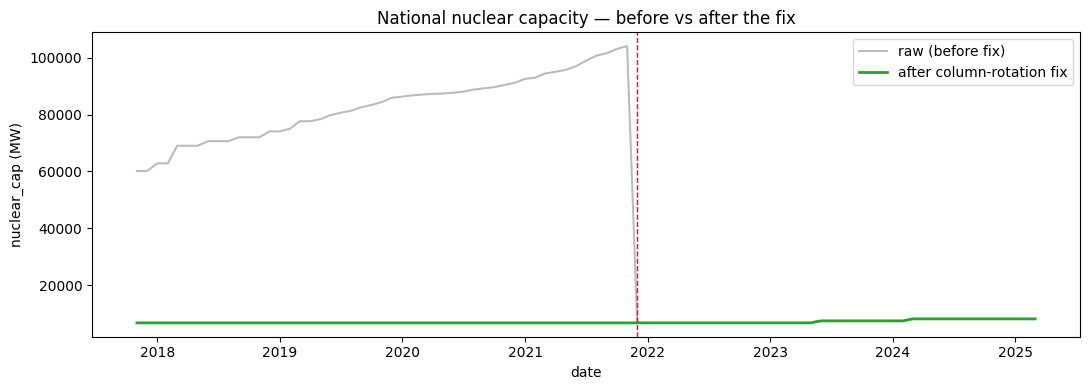

In [29]:
# Before vs after: the discontinuity should be gone in the fixed series.
nat_raw   = df.groupby("date")["nuclear_cap"].sum()
nat_fixed = fixed.groupby("date")["nuclear_cap"].sum()

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(nat_raw.index,   nat_raw.values,   color="#bbbbbb", lw=1.5,
        label="raw (before fix)")
ax.plot(nat_fixed.index, nat_fixed.values, color="#2ca02c", lw=2,
        label="after column-rotation fix")
ax.axvline(BOUNDARY, color="crimson", ls="--", lw=1)
ax.set_title("National nuclear capacity — before vs after the fix")
ax.set_xlabel("date"); ax.set_ylabel("nuclear_cap (MW)")
ax.legend()
plt.tight_layout(); plt.show()

**The green (fixed) line is smooth across Dec-2021** — no step, and the impossible
non-Central nuclear count is now **0**. As a final safety net I sweep the *whole* dataset
for any remaining on/off style discontinuities (a value jumping between 0 and a large
number month-to-month) across every fuel and every state/sector.

In [30]:
def find_onoff_jumps(data, cols, threshold=2000):
    s = data.sort_values(["state_name","sector","date"])
    hits = []
    for col in cols:
        prev = s.groupby(["state_name","sector"])[col].shift()
        mask = ((prev > threshold) & (s[col]==0)) | ((prev==0) & (s[col] > threshold))
        for _, r in s[mask].iterrows():
            hits.append((col, r.state_name, r.sector, r.date.date(), round(r[col],1)))
    return pd.DataFrame(hits, columns=["col","state","sector","date","val"])

find_onoff_jumps(fixed, CAPS)

,col,state,sector,date,val
0,lignite_cap,Tamil Nadu,Central,2021-12-01,3390.0


**No residual discontinuities anywhere.** The sweep returns an empty frame, so the
rotation was the only structural defect and it's fully resolved.

### Lignite spike 
Coal and lignite are both solid-fuel thermal and are frequently reported together.
Before merging them I check whether they behave like a matched pair across the boundary
(i.e. capacity moving between the two), which would justify treating them as one series.

In [31]:
piv = fixed[fixed.date.isin([LAST_BAD, BOUNDARY])] \
        .pivot_table(index=["state_name","sector"], columns="date",
                     values=["coal_cap","lignite_cap"])
delta = pd.DataFrame({
    "coal_delta":    piv["coal_cap"][BOUNDARY]    - piv["coal_cap"][LAST_BAD],
    "lignite_delta": piv["lignite_cap"][BOUNDARY] - piv["lignite_cap"][LAST_BAD],
})
delta[delta.abs().sum(axis=1) > 0.5].round(1)

coal_delta  lignite_delta
state_name sector                            
Gujarat    Private      -500.0          500.0
           State        -900.0          900.0
Rajasthan  Central      -250.0          250.0
           Private     -1080.0         1080.0
           State        -250.0          250.0
Tamil Nadu Central     -3390.0         3390.0
           Private       275.0          250.0

 `coal_cap` + `lignite_cap` → `coal_lignite_cap` The deltas show the
two are effectively interchangeable reporting buckets for the same thermal capacity;
keeping them split adds noise without analytical value. I'll do the merge in §11 (after
the sector view below, which still uses the seven raw columns).

## consolidate coal + lignite


In [33]:
fixed["coal_lignite_cap"] = (fixed["coal_cap"] + fixed["lignite_cap"]).round(2)
fixed = fixed.drop(columns=["coal_cap","lignite_cap"])

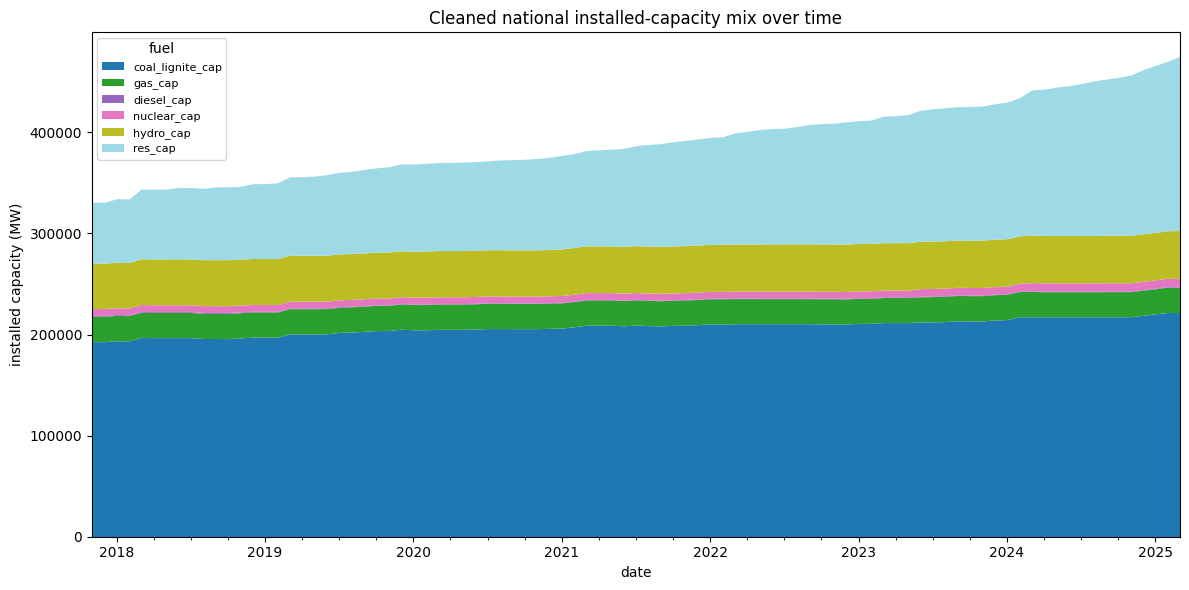

In [35]:
# Cleaned national mix over time (final six-fuel schema), as a stacked area.
mix = fixed.groupby("date")[FINAL].sum()

ax = mix.plot.area(figsize=(12, 6), linewidth=0, cmap="tab20")
ax.set_title("Cleaned national installed-capacity mix over time")
ax.set_xlabel("date"); ax.set_ylabel("installed capacity (MW)")
ax.legend(title="fuel", loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

In [34]:
df.to_csv(r"C:\Users\v-vvajpai\Desktop\Project\Project_2\datasets\installed-capacity-statewise-cleaned.csv", index=False)

**Exported** to `installed-capacity-statewise-cleaned.csv`. Note the CSV is written from
`fixed` (the cleaned frame), not the raw `df`.